In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


2026-05-22 23:01:06.756853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 23:01:06.769181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779465666.783883  497564 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779465666.788679  497564 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779465666.799754  497564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [3]:

BASE_PATHHASIL = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv2/norm/dwt/"

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models


def build_cnn_tow_ids(input_shape=(32, 32, 3)):

    inputs = layers.Input(shape=input_shape)

    # =========================================================
    # Block A
    # SeparableConv + ReLU
    # SeparableConv + ReLU
    # BatchNorm
    # MaxPooling
    # =========================================================

    x = layers.SeparableConv2D(
        32, (3,3),
        padding="same",
        use_bias=False
    )(inputs)
    x = layers.ReLU()(x)

    x = layers.SeparableConv2D(
        32, (3,3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.ReLU()(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2,2))(x)

    # =========================================================
    # Block B (Residual Block)
    #
    # shortcut:
    # Conv1x1 + BN
    #
    # main:
    # SepConv + ReLU
    # SepConv + ReLU
    # BN
    #
    # output:
    # Add + ReLU
    # =========================================================

    shortcut = layers.Conv2D(
        64,
        (1,1),
        padding="same",
        use_bias=False
    )(x)

    shortcut = layers.BatchNormalization()(shortcut)

    y = layers.SeparableConv2D(
        64,
        (3,3),
        padding="same",
        use_bias=False
    )(x)
    y = layers.ReLU()(y)

    y = layers.SeparableConv2D(
        64,
        (3,3),
        padding="same",
        use_bias=False
    )(y)
    y = layers.ReLU()(y)

    y = layers.BatchNormalization()(y)

    x = layers.Add()([y, shortcut])
    x = layers.ReLU()(x)

    # =========================================================
    # Block C
    #
    # SepConv + ReLU
    # GlobalAveragePooling
    # Dense + ReLU
    # Dense + ReLU
    # Dropout
    # Dense + Sigmoid
    # =========================================================

    x = layers.SeparableConv2D(
        128,
        (3,3),
        padding="same",
        use_bias=False
    )(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation="relu")(x)

    x = layers.Dense(256, activation="relu")(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

In [5]:

train_data = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_test_dwt.npz"))
val_data   = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

X_val   = val_data["X"]
y_val   = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

(6582, 32, 32, 3) (6582,)
(6184, 32, 32, 3) (6184,)
(2821, 32, 32, 3) (2821,)


In [6]:
tf.keras.backend.clear_session()

model = build_cnn_tow_ids()
model.summary()


I0000 00:00:1779465668.619183  497564 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4144 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 32, 32,    │        123 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 32, 32,    │      1,312 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 16, 16,    │      2,336 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ separable_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 16, 16,    │      4,672 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ separable_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 16, 16,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 16, 16,    │      8,768 │ re_lu_4[0][0]   

 Total params: 217,532 (849.73 KB)

 Trainable params: 217,212 (848.48 KB)

 Non-trainable params: 320 (1.25 KB)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    
)


Epoch 1/50


I0000 00:00:1779465671.406964  497698 service.cc:152] XLA service 0x7f08380027f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779465671.406987  497698 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-22 23:01:11.470736: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779465671.875823  497698 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-05-22 23:01:12.810622: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485_0', 44 bytes spill stores, 44 bytes spill loads

2026-05-22 23:01:13.689616: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

193/206 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8150 - loss: 0.4372 - precision: 0.8927 - recall: 0.7319

2026-05-22 23:01:23.204602: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2261', 28 bytes spill stores, 32 bytes spill loads

2026-05-22 23:01:23.326173: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485_0', 36 bytes spill stores, 36 bytes spill loads

2026-05-22 23:01:23.448296: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1485', 488 bytes spill stores, 488 bytes spill loads

2026-05-22 23:01:24.550416: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2263', 28 bytes spill stores, 32 bytes spill loads

2026-05-22 23:01:25.200699: I extern

206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8186 - loss: 0.4303 - precision: 0.8946 - recall: 0.7378

2026-05-22 23:01:33.907464: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 64 bytes spill stores, 64 bytes spill loads



206/206 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.8741 - loss: 0.3262 - precision: 0.9238 - recall: 0.8276 - val_accuracy: 0.6856 - val_loss: 0.8838 - val_precision: 0.6856 - val_recall: 1.0000
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9362 - loss: 0.1852 - precision: 0.9590 - recall: 0.9173 - val_accuracy: 0.6856 - val_loss: 0.9705 - val_precision: 0.6856 - val_recall: 1.0000
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9485 - loss: 0.1561 - precision: 0.9652 - recall: 0.9353 - val_accuracy: 0.9454 - val_loss: 0.1535 - val_precision: 0.9729 - val_recall: 0.9467
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9564 - loss: 0.1363 - precision: 0.9702 - recall: 0.9457 - val_accuracy: 0.9458 - val_loss: 0.1595 - val_precision: 0.9928 - val_recall: 0.9276
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9564 - loss: 0.1288 - precision: 0.9688 - recall: 0.9472 - val_accuracy: 0.9599 - val_loss: 0.1273 - va

In [8]:
# =========================
# CELL 1
# =========================

import numpy as np
from sklearn.metrics import roc_curve

# prediksi probabilitas
y_prob = model.predict(X_test).ravel()

# label asli
y_true = y_test

# =========================
# EVALUASI DEFAULT THRESHOLD 0.5
# =========================

default_threshold = 0.5
y_pred_default = (y_prob >= default_threshold).astype(int)

# =========================
# CARI THRESHOLD TERBAIK
# =========================
# strategi:
# cari threshold dengan F1 tertinggi

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for th in thresholds:

    y_pred_temp = (y_prob >= th).astype(int)

    TP = np.sum((y_true == 1) & (y_pred_temp == 1))
    TN = np.sum((y_true == 0) & (y_pred_temp == 0))
    FP = np.sum((y_true == 0) & (y_pred_temp == 1))
    FN = np.sum((y_true == 1) & (y_pred_temp == 0))

    precision = TP / (TP + FP + 1e-12)
    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best Threshold:", best_threshold)
print("Best F1 Score :", best_f1)

# prediksi final threshold terbaik
y_pred_best = (y_prob >= best_threshold).astype(int)

165/194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-05-22 23:02:28.307345: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_138', 64 bytes spill stores, 64 bytes spill loads



194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step
Best Threshold: 0.20999999999999996
Best F1 Score : 0.8979143798019162


In [9]:
# =========================
# CELL 2
# =========================

from sklearn.metrics import confusion_matrix

# ===== DEFAULT 0.5 =====
cm_default = confusion_matrix(y_true, y_pred_default)

TN_d, FP_d, FN_d, TP_d = cm_default.ravel()

print("=== Confusion Matrix (Threshold = 0.5) ===")
print(cm_default)

# ===== BEST THRESHOLD =====
cm_best = confusion_matrix(y_true, y_pred_best)

TN_b, FP_b, FN_b, TP_b = cm_best.ravel()

print("\n=== Confusion Matrix (Best Threshold) ===")
print(cm_best)

=== Confusion Matrix (Threshold = 0.5) ===
[[3220   76]
 [ 495 2393]]

=== Confusion Matrix (Best Threshold) ===
[[3172  124]
 [ 434 2454]]


In [10]:
# =========================
# CELL 3
# =========================

def calculate_metrics(TN, FP, FN, TP):

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP + 1e-12)

    recall = TP / (TP + FN + 1e-12)

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    FPR = FP / (FP + TN + 1e-12)

    FNR = FN / (FN + TP + 1e-12)

    return accuracy, precision, recall, f1, FPR, FNR


# ===== DEFAULT =====
metrics_default = calculate_metrics(TN_d, FP_d, FN_d, TP_d)

# ===== BEST =====
metrics_best = calculate_metrics(TN_b, FP_b, FN_b, TP_b)

In [11]:
# =========================
# CELL 4
# =========================

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FNR"
]

print("========================================")
print("THRESHOLD = 0.5")
print("========================================")

for name, value in zip(metric_names, metrics_default):
    print(f"{name:10}: {value:.6f}")

print("\n")

print("========================================")
print(f"BEST THRESHOLD = {best_threshold:.2f}")
print("========================================")

for name, value in zip(metric_names, metrics_best):
    print(f"{name:10}: {value:.6f}")

THRESHOLD = 0.5
Accuracy  : 0.907665
Precision : 0.969218
Recall    : 0.828601
F1-score  : 0.893410
FPR       : 0.023058
FNR       : 0.171399


BEST THRESHOLD = 0.21
Accuracy  : 0.909767
Precision : 0.951901
Recall    : 0.849723
F1-score  : 0.897914
FPR       : 0.037621
FNR       : 0.150277


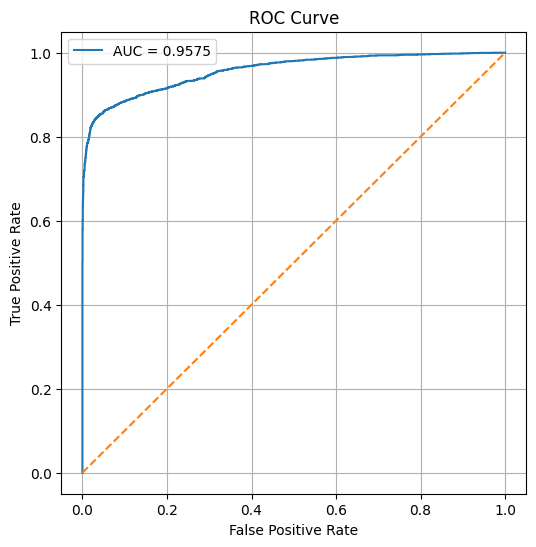

In [12]:
# =========================
# CELL 5
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()